# Film Data Analysis: Proposing Key Features for Profitable Movies

I will analyse movie data to find key features for profitable movies. The purpose is to use these insights for decision-making in the next movie production. I will begin by cleaning the data, then explore it and finally conduct a hypothesis test. 

In [1]:
#this is a code cell. Write the code that you want to do things in it. Include some comments with the code to
#explain what you are doing, where appropriate.

myfile='movie_metadata.csv'
#standard imports for when working with pandas
import numpy as np
#matplotlib inline
from matplotlib import pyplot as plt
import pandas as pd

# myfile = 'movie_metadata.csv'

#read the movie metadata file into a dataframe in pandas.
df = pd.read_csv(myfile,index_col=None)


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [3]:
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


# Data Cleaning1

## Make new columns

- "profit": "gross" - "budget"
- "num_genre": the number of genres each movie is classified into
- "director_appear": the number of appearances for each director in the data
- "actor_1_appear": the number of appearances for eacg actor_1 in the data

In [4]:
# make a new column "profit"
df["profit"] = df["gross"] - df["budget"]

In [5]:
# make a new column "num_genre"

# making a list that holds the numbers of genres each movie is classified
count_list = []
for genre in df.genres:
    counter = 0
    for letter in genre:
        if str(letter) == "|":
            counter += 1

    count_list.append(counter + 1) # the number of genres = the number of "|" + 1 

# adding the column
df["num_genre"] = count_list

In [6]:
# make new columns "director_appear" and "actor_1_appear"

def appear_col(df, col): # col: "col_name"
    name_dic = {}        # make a dictionary that holds {"name": no. of apperance}
    for name in df[col].unique():
        name_dic[name] = df[df[col] == name].count()[0] # how many time each actor appears
    
    appear_list = []
    for idx, name in enumerate(df[col]):
        if name in name_dic:
            appear_list.append(name_dic[name]) # append values
    return appear_list

I interpreted that a higher frequency of appearances in 'director_appear' and 'actor_1' suggests more experienced individuals

In [7]:
df["director_appear"] = appear_col(df, "director_name")
df["actor_1_appear"] = appear_col(df, "actor_1_name")

# Data cleaning 2

## Organize the data

- Change the order of columns
- Delete rows where "profit" is null
- Change "title_year" datatype
- Delete white spances in "color"
- Delete "\xa0" in "movie_title"
- Fix some country names in "country"
- Replace "Not Rated" with "Unrated" in "content_rating"
- Drop duplicates in "movie_title"

In [8]:
# organize the order of the columns 1
# check what columns we have
df.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes', 'profit',
       'num_genre', 'director_appear', 'actor_1_appear'],
      dtype='object')

In [9]:
# change the order of columns
# How to change column orders: https://www.educative.io/answers/how-to-change-the-order-of-columns-of-a-dataframe-in-pandas

columns = [
    'movie_title', # have to deal with "\ax0", duplicate data
    'budget',
    'gross',
    'profit', # budget - gross, outliers
    'genres',
    'num_genre', # the number of genres each movie is classified
    'plot_keywords', # most of them are unique
    'duration',
    'imdb_score',
    'num_user_for_reviews',
    'num_critic_for_reviews',
    'num_voted_users',
    'color',
    'title_year', # float to int
    'aspect_ratio',
    'language',
    'country', # some countries are not actual countries
    'director_name',
    'director_facebook_likes',
    'director_appear',
    'actor_1_name',
    'actor_1_facebook_likes',
    'actor_1_appear',
    'actor_2_name',
    'actor_2_facebook_likes',
    'actor_3_name',
    'actor_3_facebook_likes',
    'cast_total_facebook_likes',
    'movie_facebook_likes',
    'facenumber_in_poster',
    'content_rating', # eg) PG-13
    'movie_imdb_link' # unique value
    ]

# change the data using the list made in the previous cell
df = df[columns]

In [10]:
# eliminate null values

null_df = df[df["profit"].isnull()].index # get indeces where "profit" is null
df.drop(null_df, inplace = True) # drop the null data
df.reset_index(drop=True, inplace=True) # reset indices

In [11]:
# float to int
# How to convert froat to int: https://stackoverflow.com/questions/43956335/convert-float64-column-to-int64-in-pandas
df["title_year"] = df["title_year"].astype(np.int64)

In [12]:
# delete white spaces
df["color"] = df["color"].str.replace(" Black and White","Black and White")

In [13]:
# delete "\xa0"
new_mt = []
for title in df.movie_title:
    new_mt.append(title.strip("\xa0"))

df["movie_title"] = new_mt

In [14]:
# fix country names
# How to extract rows that include certain letters: https://stackoverflow.com/questions/27975069/how-to-filter-rows-containing-a-string-pattern-from-a-pandas-dataframe

# American movie
df["country"]=df["country"].str.replace("New Line","USA") # movie_title: "Town & Country", https://en.wikipedia.org/wiki/Town_%26_Country_(film)
df["country"]=df["country"].str.replace("Official site","USA") # movie_title: "Country Strong", https://en.wikipedia.org/wiki/Country_Strong
df["country"]=df["country"].str.replace("Aruba","USA") # movie_title: "Knock Off", https://en.wikipedia.org/wiki/Knock_Off_(film)

# German movie
df["country"]=df["country"].str.replace("West Germany","Germany") # movie_title: Das Boot
# Das Boot: https://en.wikipedia.org/wiki/Das_Boot

In [15]:
#replace "Not Rated" with "Unrated"
df["content_rating"]=df["content_rating"].str.replace("Not Rated","Unrated")

In [16]:
# remove duplicates
df.movie_title.value_counts() # eliminate duplicates, keeps the first one(from Lab_2_solns.ipynb)
df.drop_duplicates("movie_title", keep="first", inplace=True, ignore_index=True)

# Data cleaning 3

## Drop more data
- Check whether the same name is recognized as a different name by converting uppercase letters to lowercase and removing white spaces
- Check whether columns with many null values can be dropped, and drop them if possible
- Remove remaining null values

In [17]:
# normalize data
def norm_func(col):
    norm_list = []
    for name in col:
        norm_list.append(str(name).lower().replace(" ", "")) # lower names and eliminate white space
    return (len(col), len(norm_list)) # compare the lengths of original and normalized columns

In [18]:
# check if the lengths of original and normalized columns are the same
ob_list = ["movie_title", "genres", "color", "language", "country", "director_name", "actor_1_name", "actor_2_name", "actor_3_name", "content_rating"]

for col in ob_list:
    print(col, norm_func(df[col].unique()))

movie_title (3789, 3789)
genres (762, 762)
color (3, 3)
language (38, 38)
country (43, 43)
director_name (1753, 1753)
actor_1_name (1509, 1509)
actor_2_name (2288, 2288)
actor_3_name (2688, 2688)
content_rating (12, 12)


In [19]:
# count the number of null data
for column in df.columns:
    print(column, df[column].isnull().sum())

movie_title 0
budget 0
gross 0
profit 0
genres 0
num_genre 0
plot_keywords 31
duration 1
imdb_score 0
num_user_for_reviews 0
num_critic_for_reviews 1
num_voted_users 0
color 2
title_year 0
aspect_ratio 74
language 4
country 0
director_name 0
director_facebook_likes 0
director_appear 0
actor_1_name 3
actor_1_facebook_likes 3
actor_1_appear 0
actor_2_name 5
actor_2_facebook_likes 5
actor_3_name 10
actor_3_facebook_likes 10
cast_total_facebook_likes 0
movie_facebook_likes 0
facenumber_in_poster 6
content_rating 51
movie_imdb_link 0


I droped the columns below due to the following reasons:

1. "aspect_ratio": The entry "16." appears to be a typo.
2. "content_rating": "GP" is not defined in IMDB, and the definition of "PG" varies across countries.
(IMDB Content Rating https://help.imdb.com/article/contribution/titles/certificates/GU757M8ZJ9ZPXB39?ref_=helpart_nav_27#)
3. "plot_keywords": Most of them are unique items and challenging to analyze.

In [20]:
# check if I can drop the columns: "plot_keywords", "aspect_ratio", and "content_rating"
# I'll drop them

print("'aspect_ratio' unique values:\n", df.aspect_ratio.unique(),"\n") 
print("'content_rating' unique values:\n", df.content_rating.unique(),"\n") 
print("The number of 'plot_keywords' unique values:\n", len(df.plot_keywords.unique()))

'aspect_ratio' unique values:
 [ 1.78  2.35  1.85  2.    2.2   2.39  2.24  1.66  1.5   1.77  2.4   1.37
   nan  2.76  1.33  1.18  2.55  1.75 16.  ] 

'content_rating' unique values:
 ['PG-13' 'PG' 'G' 'R' 'Approved' 'NC-17' nan 'X' 'Unrated' 'M' 'GP'
 'Passed'] 

The number of 'plot_keywords' unique values:
 3759


In [21]:
# remove remaining null values
del_col = ["duration", "num_critic_for_reviews", "color", "language", "actor_1_name",
           "actor_1_facebook_likes", "actor_2_name", "actor_2_facebook_likes",
           "actor_3_name", "actor_3_facebook_likes", "facenumber_in_poster"]

In [22]:
for col in del_col:
    null_idx = (df[df[col].isnull()].index)
    df.drop(null_idx, inplace = True)

df.reset_index(drop=True, inplace=True)

# Data Exploration

In [23]:
# extract columns that I need
new_columns = [
    'movie_title', 
    'budget',
    'gross',
    'profit', # budget - gross
    'genres',
    'num_genre',
    # 'plot_keywords',
    'duration',
    'imdb_score', 
    'num_user_for_reviews',
    'num_critic_for_reviews',
    'num_voted_users',
    'color',
    'title_year',
    # 'aspect_ratio',
    'language',
    'country',
    'director_name',
    'director_facebook_likes',
    'director_appear',
    'actor_1_name',
    'actor_1_facebook_likes',
    'actor_1_appear',
    'actor_2_name',
    'actor_2_facebook_likes',
    'actor_3_name',
    'actor_3_facebook_likes',
    'cast_total_facebook_likes',
    'movie_facebook_likes',
    'facenumber_in_poster',
    # 'content_rating', # eg) PG-13
    # 'movie_imdb_link'
    ]

df = df[new_columns]

I identified data points with significantly large budgets and excluded them as outliers. The highest movie budget was $435,000,000(approximately £350,000,000) according to the website below. Additionaly, the budgets for the two least expensive movies were in USD. Based on these criteria, I have determined the upper bound and lower bound.

Most expensive films (adjusted for inflation): https://www.imdb.com/list/ls507929474/

In [24]:
# outliers
# most expensive films budget 435,000,000 USD = 347,151,750 GBP ※ 1 USD = 0.8 GBP
# the two least expensive movie budgets
# 1. Tarnation(218 USD): https://en.wikipedia.org/wiki/Tarnation_(2003_film)
# 2. My Date with Drew(1100 USD): https://en.wikipedia.org/wiki/My_Date_with_Drew
upper_bound = 350000000
lower_bound = 1100

u_idx = df[df.budget > upper_bound].index
l_idx = df[df.budget <= lower_bound].index # include £1,100
df.drop(u_idx, inplace = True)
df.drop(l_idx, inplace = True)

df.reset_index(drop=True, inplace=True)

From the following histplot and boxplot, it is clear that the data is skewed.

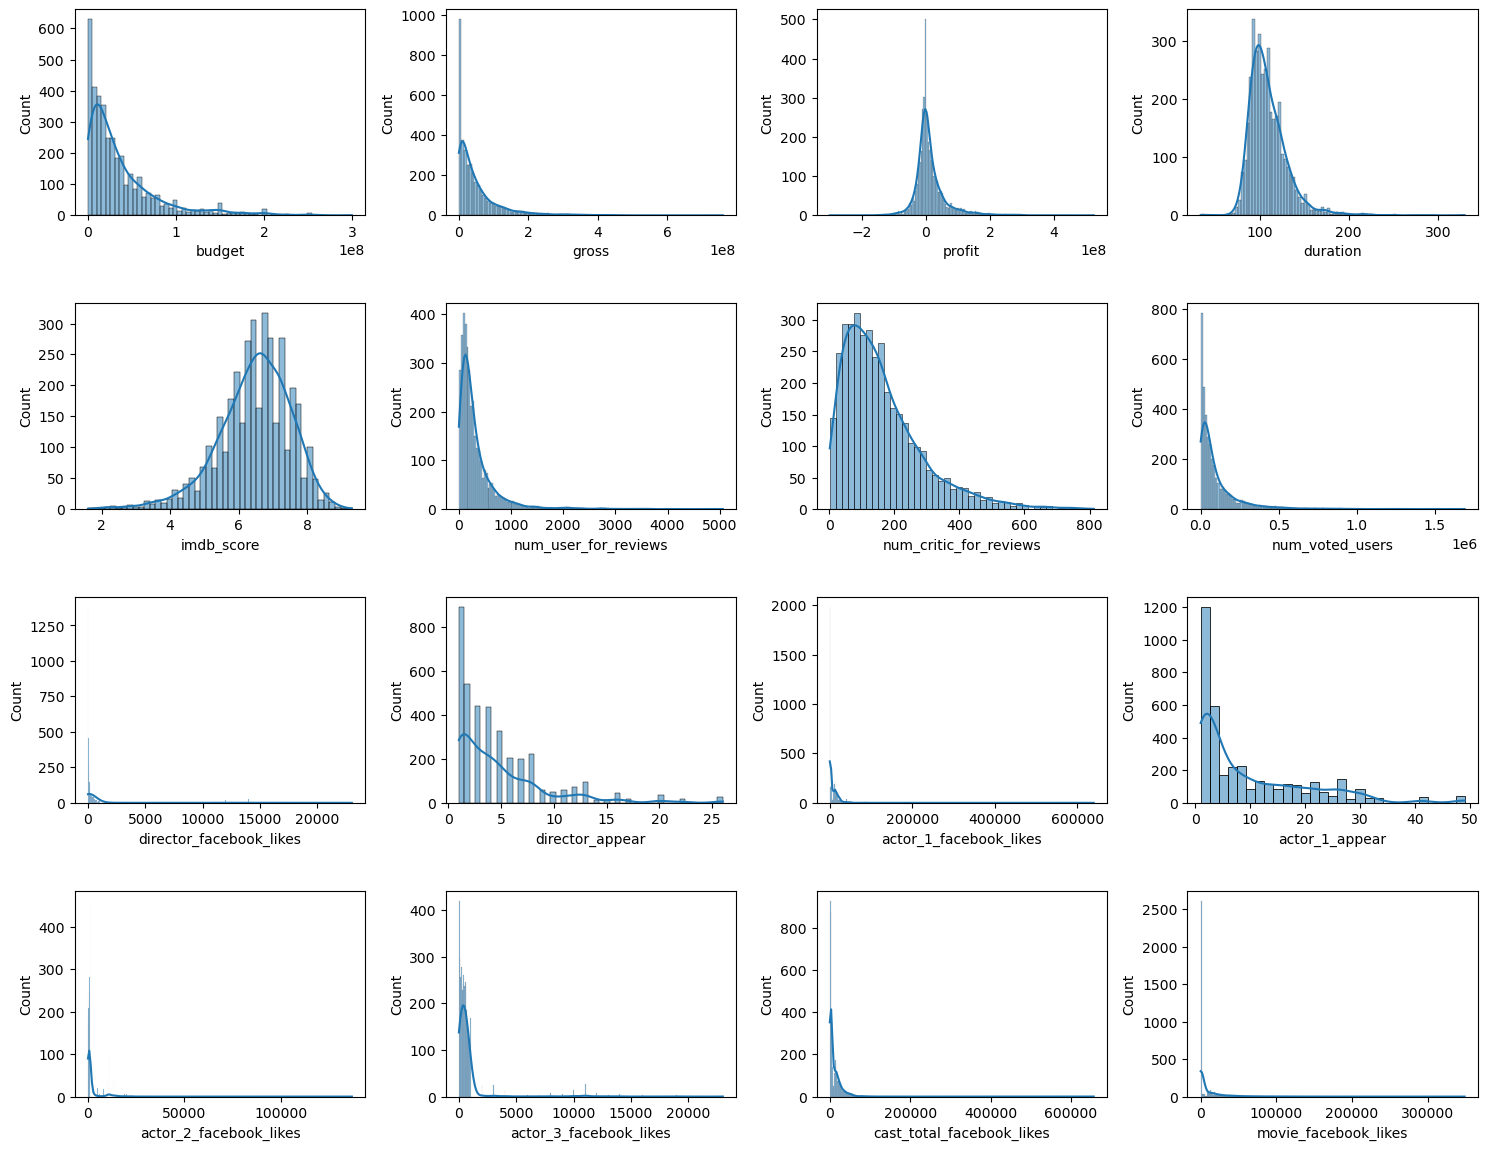

In [25]:
# visualize data
import matplotlib.pyplot as plt
import seaborn as sns

con_list = ["budget", "gross", "profit", "duration", "imdb_score", "num_user_for_reviews", "num_critic_for_reviews", "num_voted_users", "director_facebook_likes", "director_appear", "actor_1_facebook_likes", "actor_1_appear", "actor_2_facebook_likes", "actor_3_facebook_likes", "cast_total_facebook_likes", "movie_facebook_likes"]
cat_list = ["num_genre", "color", "title_year", "language", "country", "director_name", "actor_1_name", "actor_2_name", "actor_3_name", "facenumber_in_poster"]

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15,8))
for column, ax in zip(con_list, axes.flat):
    sns.histplot(x=df[column], ax=ax, kde=True)
fig.tight_layout()
fig.set_figheight(fig.get_figheight() * 1.5)

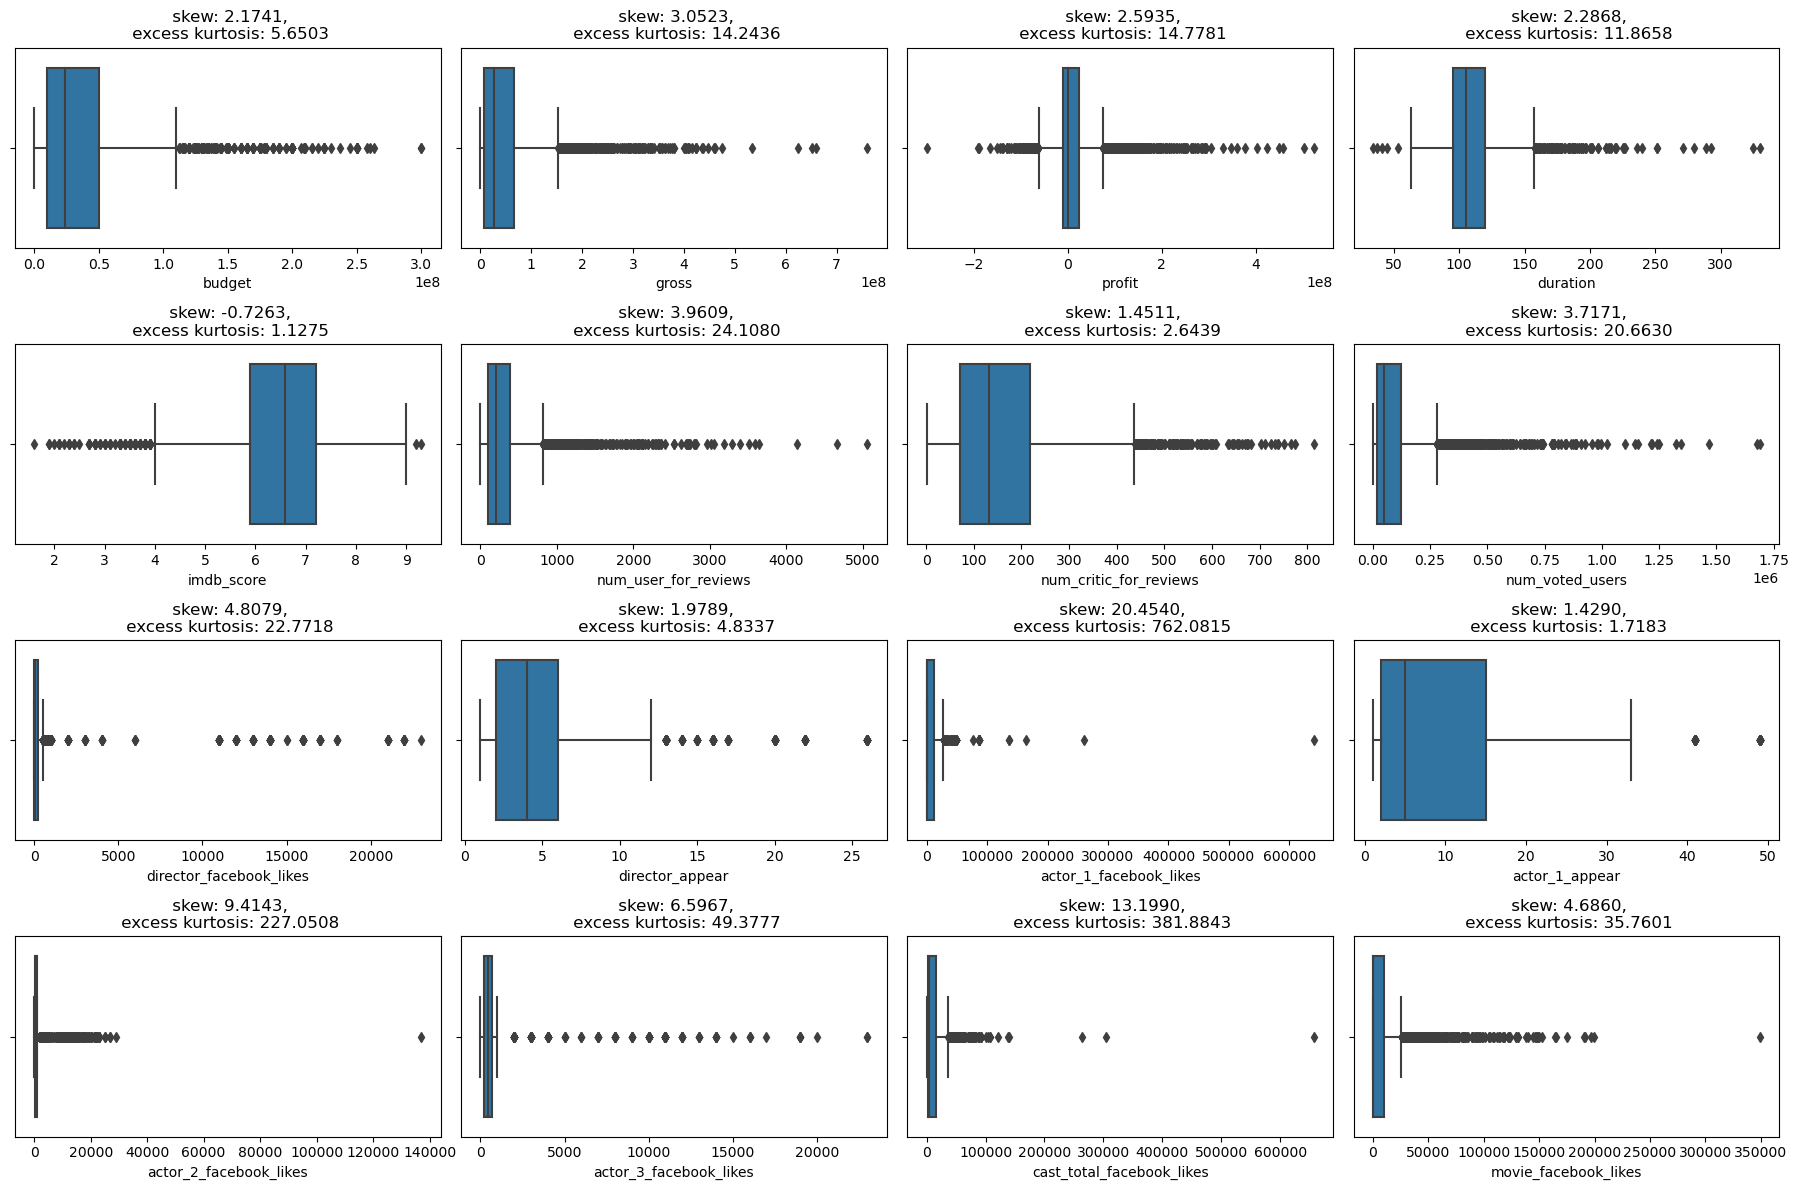

In [26]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18,12))
for column, ax in zip(con_list, axes.flat):
    sns.boxplot(x=df[column], ax=ax)
    # calculate skew and kurt(from Lab_5_solns.ipynb)
    skew = df[column].skew() 
    kurt = df[column].kurtosis()
    ax.set_title(f" skew: {skew:.4f},\n excess kurtosis: {kurt:.4f}")
fig.tight_layout()

The Q-Q plot below indicates that data does not follow a Gaussian distribution except "imdb_score".

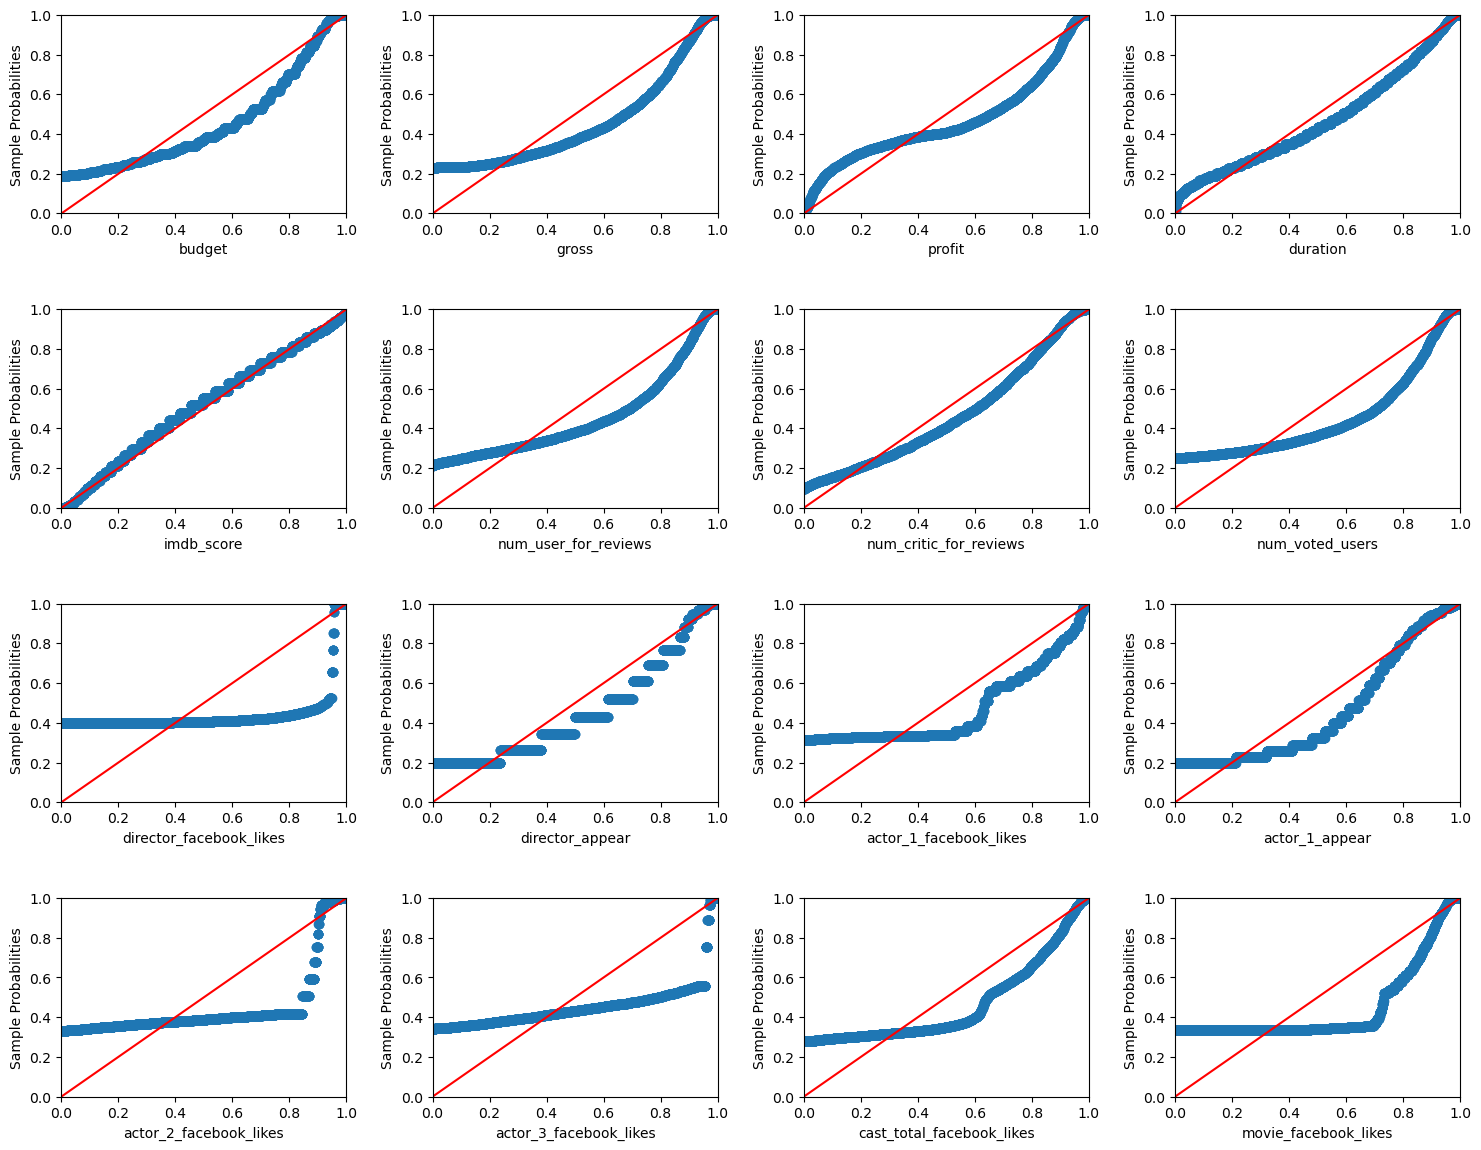

In [27]:
import statsmodels.api as sm
from scipy.stats import norm

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15,8))

for col, ax in zip(con_list, axes.flat):
    pp_x = sm.ProbPlot(df[col], dist=norm, fit=True)
    pp_x.ppplot(line="45",ax=ax)
    ax.set_xlabel(col)

fig.tight_layout()
fig.set_figheight(fig.get_figheight() * 1.5)

In [28]:
# Pearson's correlation coefficient(from Lab_3_solns.ipynb)
def pearsons(x_data,y_data):
    x_mean = np.mean(x_data)
    y_mean = np.mean(y_data)

    if not isinstance(x_data,np.ndarray):
        x_data = np.array(x_data)

    if not isinstance(y_data,np.ndarray):
        y_data = np.array(y_data)

    xy_cov = np.sum((x_data - x_mean) * (y_data - y_mean))
    x_std = np.sqrt(np.sum((x_data - x_mean)**2.0))
    y_std = np.sqrt(np.sum((y_data - y_mean)**2.0))
    return xy_cov/(x_std * y_std)

The scatter plot below shows a positive correlation only between "gross" and "profit".

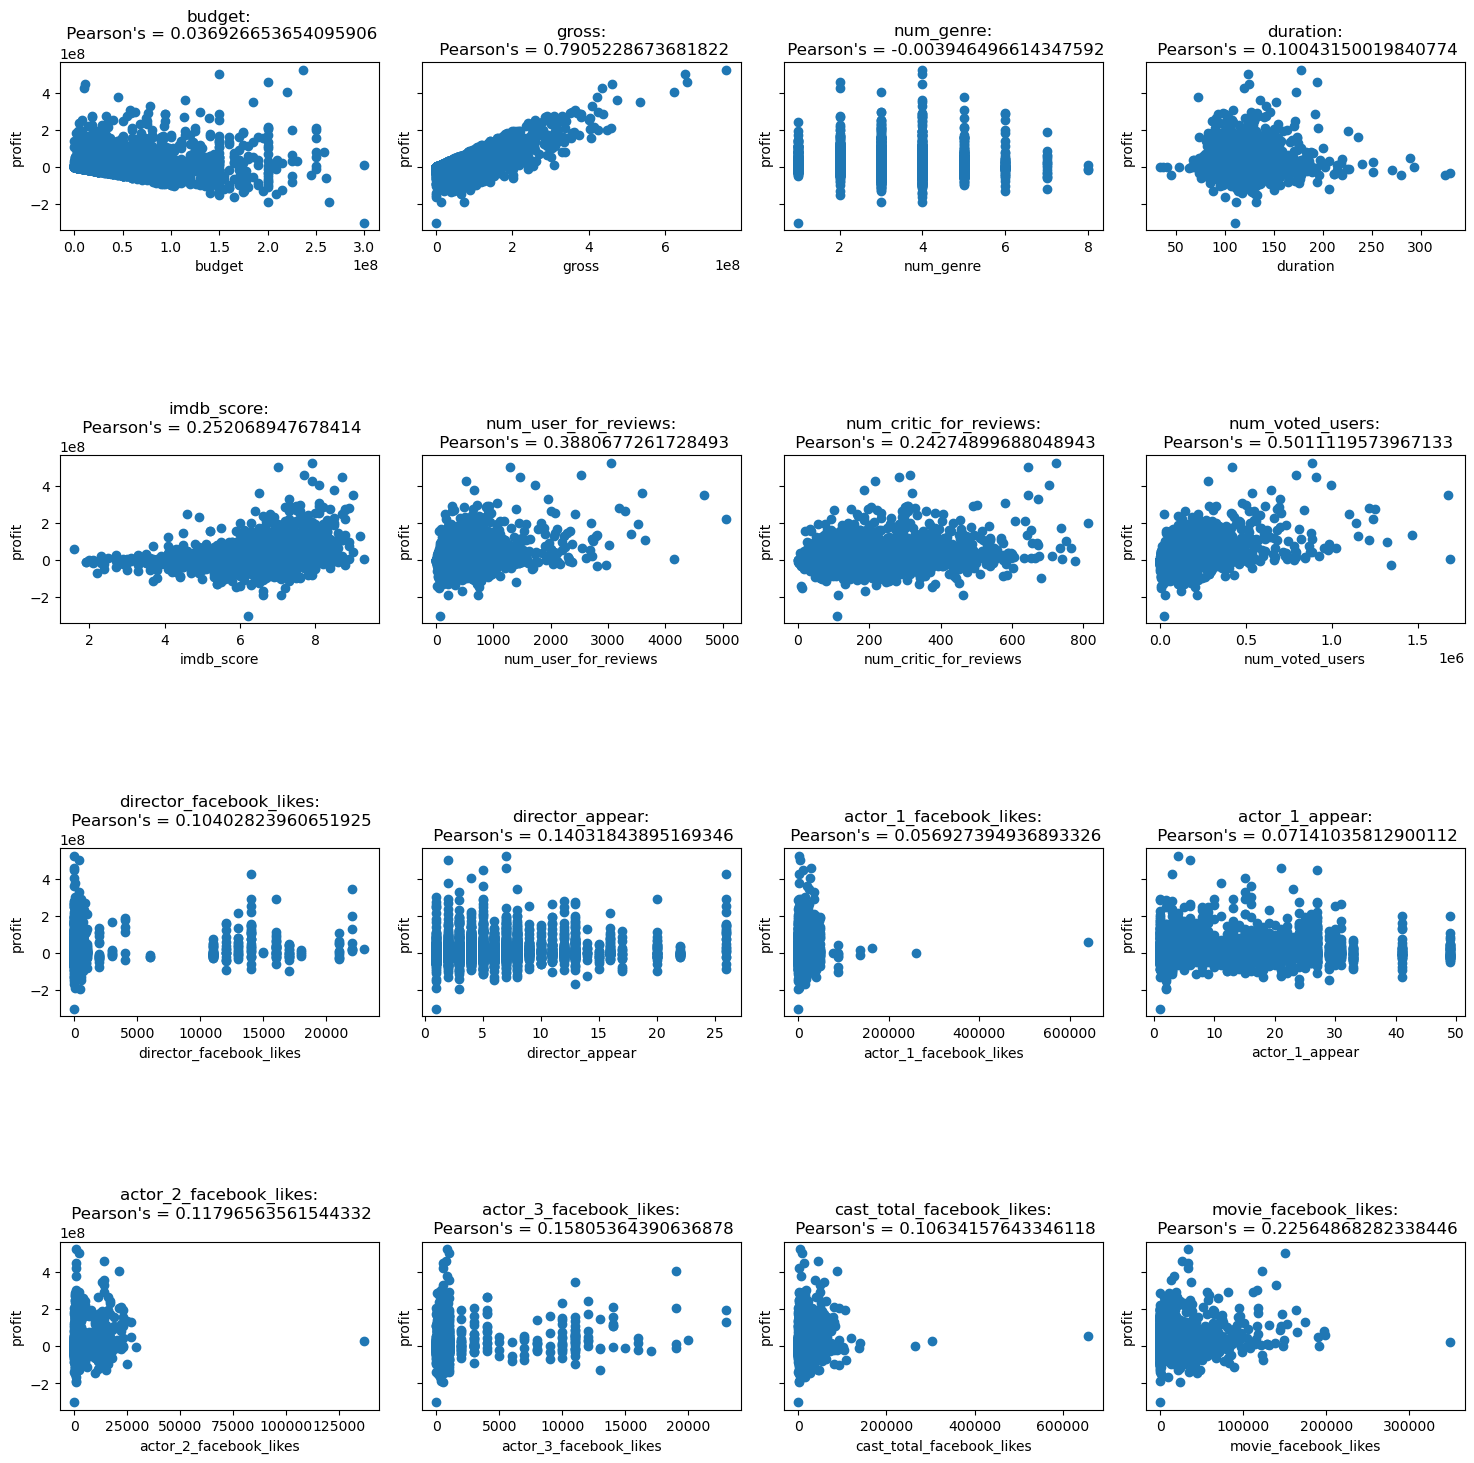

In [29]:
# profit and each column
con_list1 = ["budget", "gross", "num_genre", "duration", "imdb_score", "num_user_for_reviews", "num_critic_for_reviews", "num_voted_users", "director_facebook_likes", "director_appear", "actor_1_facebook_likes", "actor_1_appear", "actor_2_facebook_likes", "actor_3_facebook_likes", "cast_total_facebook_likes", "movie_facebook_likes"]
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15,8), sharey=True)

for col, ax in zip(con_list1, axes.flat):
    ax.scatter(df[col], df.profit)
    # Pearson's correlation coefficient to examine a linear relationship
    ax.set_title(f"{col}:\n Pearson's = {pearsons(df[col], df.profit)}")
    ax.set_xlabel(col)
    ax.set_ylabel("profit")

fig.tight_layout()
fig.set_figheight(fig.get_figheight() * 2.0)

I analyzed what went wrong with the previous movie. It had three features: a budget of 500,000, that the number of genres was three, and that it was categolized as "Action|Comedy|Thriller".

In [30]:
# genres based on IMDB's genre definition: https://help.imdb.com/article/contribution/titles/genres/GZDRMS6R742JRGAG#
# deleted some genres that did not appear or appears only once in the data
genre_list = ["Action", "Adventure", "Animation", "Biography", "Comedy", "Crime", "Documentary", "Drama", "Family", "Fantasy", "History", "Horror", "Musical", "Music", "Mystery", "Romance", "Sci-Fi", "Sport", "Thriller", "War", "Western"]

In [31]:
# spearman's correlation coefficient(from Lab_3_solns.ipynb)
def ranking_mapping(data):
    arg_sort = np.argsort(data) # argsort: retrieve the array ndarray of the sorted indices
    return {a : i for i,a in enumerate(arg_sort)}

def spearmans(x_data,y_data):
    x_rank_map = ranking_mapping(x_data)
    y_rank_map = ranking_mapping(y_data)
    n = len(x_data)

    ranking = np.sum([(x_rank_map[k] - y_rank_map[k]) ** 2.0 for k in range(n)])
    return 1.0 - 6.0*ranking/(n**3.0 - n)

The following graph is a scatter plot of "budget" and "profit" for each genre. There is not much correlation observed in any genre.

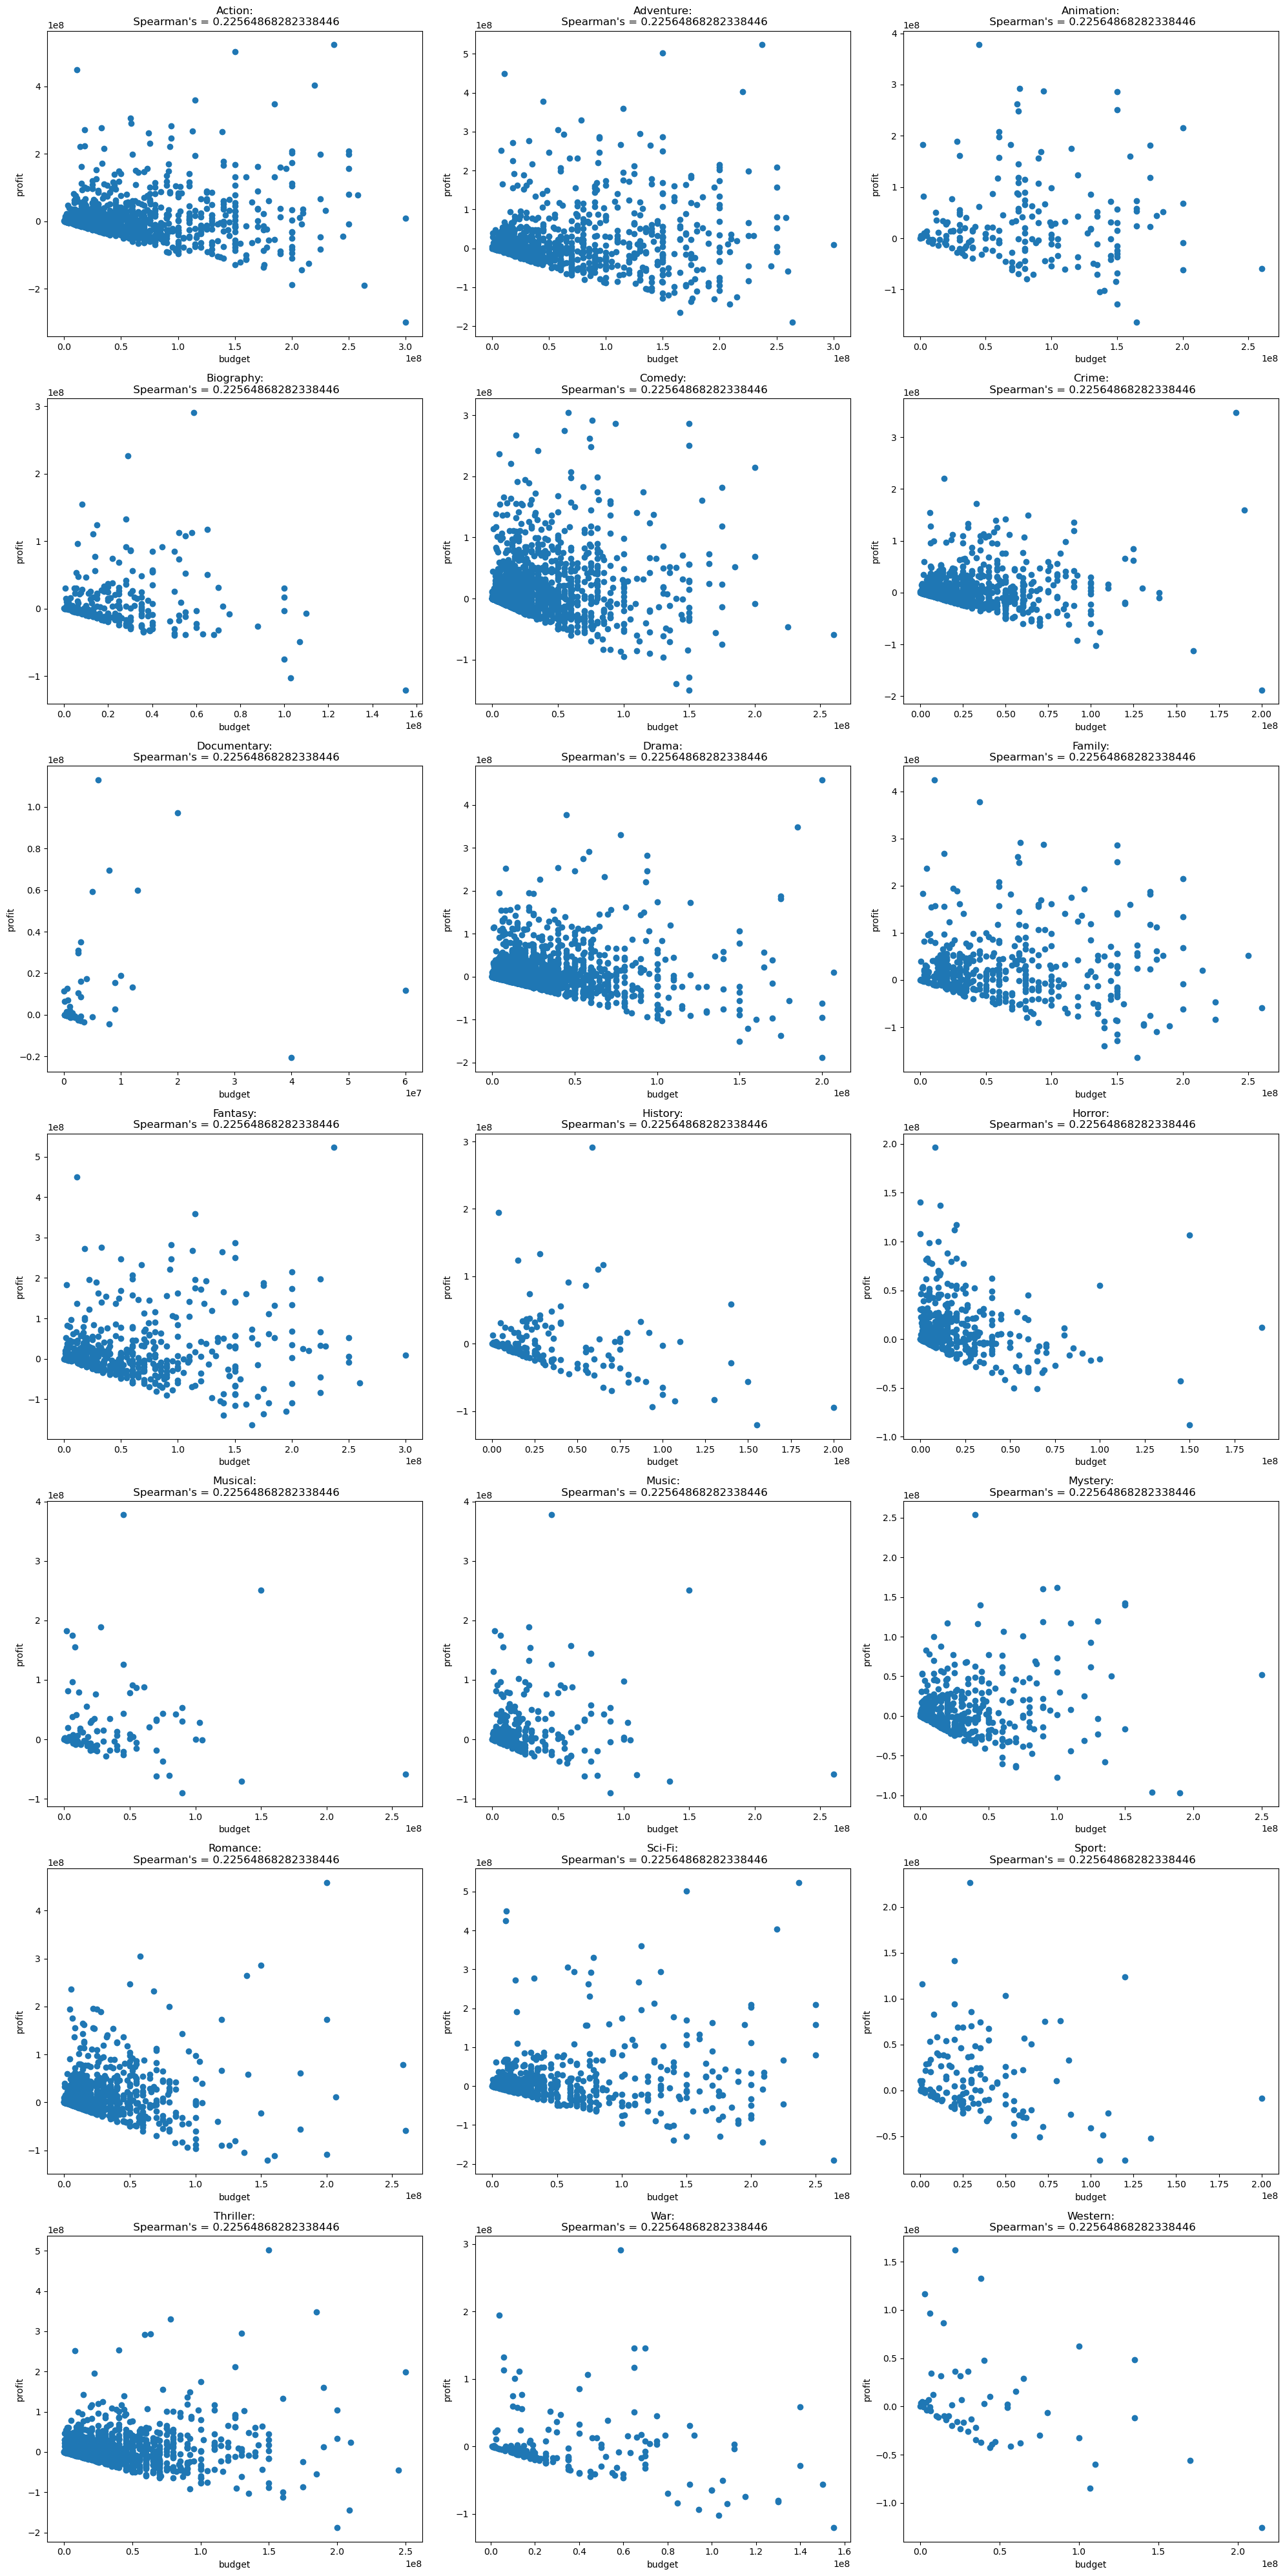

In [32]:
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(20,40))

for genre, ax in zip(genre_list, axes.flat):
    ge_df = df[df["genres"].str.contains(genre)]
    ax.scatter(ge_df.budget, ge_df.profit)
    # Spearman's correlation coefficient to see a relationship between variables
    ax.set_title(f"{genre}:\n Spearman's = {pearsons(df[col], df.profit)}")
    ax.set_xlabel("budget")
    ax.set_ylabel("profit")
    
fig.tight_layout()

In [33]:
# color certain cells
# How to color cells: https://pandas.pydata.org/pandas-docs/version/0.17.1/style.html

def color_negative_red(val):
    """
    Takes a scalar and returns a string with
    the css property `'color: red'` for negative
    strings, black otherwise.
    """
    color = 'red' if val < 0 else 'black'
    return 'color: %s' % color

Here, I extracted movies with features similar to the last movie and compared their averages, among other factors.

The combination of "Comedy" and "Thriller" appears to be challenging. Attempting to create contrasting atmospheres within a single movie might have led to difficulties and could be the reason for the failure.

In [34]:
# Was the combination of "Action, Comedy, and Thriller" really good?

# Action, Comedy, and Thriller
l1 = list(df[df["genres"].str.contains("Action") & df["genres"].str.contains("Comedy") & df["genres"].str.contains("Thriller")].describe()["profit"])
# Action and Comedy
l2 = list(df[(df["genres"].str.contains("Action")) & (df["genres"].str.contains("Comedy"))].describe()["profit"])
# Action and Thriller
l3 = list(df[(df["genres"].str.contains("Action")) & (df["genres"].str.contains("Thriller"))].describe()["profit"])
# Comedy and Thriller
l4 = list(df[(df["genres"].str.contains("Comedy")) & (df["genres"].str.contains("Thriller"))].describe()["profit"])
# budget == 500000
l5 = list(df[df["budget"] == 500000].describe()["profit"])
# the number of genres == 3
l6 = list(df[df["num_genre"] == 3].describe()["profit"])

# indices
ind_list = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
# columns
col_list = ["Action|Comedy|Thriller", "Action|Comedy", "Action|Thriller", "Comedy|Thriller", "budget:500K", "3 genres"]

genre_df = pd.DataFrame(zip(l1,l2,l3,l4,l5,l6), index=ind_list, columns=col_list)
genre_df = genre_df.style.applymap(color_negative_red)

genre_df

,Action|Comedy|Thriller,Action|Comedy,Action|Thriller,Comedy|Thriller,budget:500K,3 genres
count,57.000000,217.000000,491.000000,108.000000,33.000000,1251.000000
mean,-251122.736842,13473949.161290,5816766.582485,-2014829.379630,4306046.727273,12108339.442046
std,36296250.070258,55669302.047242,51490041.218399,29645795.365648,10405903.547346,49900997.181260
min,-61357548.000000,-128620685.000000,-188094481.000000,-61357548.000000,-498668.000000,-190641321.000000
25%,-23979782.000000,-18891023.000000,-20445688.000000,-19368934.750000,-451570.000000,-10660189.000000
50%,-6198245.000000,3738726.000000,-1156686.000000,-3288751.500000,-256653.000000,999622.000000
75%,13257000.000000,28771072.000000,21414972.000000,10621375.250000,750798.000000,23664549.000000
max,136138454.000000,305024263.000000,502177271.000000,136138454.000000,39052600.000000,403279547.000000


Additionally, we can see that the profit is generally higher for "Color" movies. Therefore, it seems reasonable to opt for a color movie.

In [35]:
# tabel: "color" and "profit"

# the number of rows where "color" is "Black and White" and "profit" >= 0
bw_p = df[(df.color == "Black and White") & (df["profit"] >= 0)].count()

# the number of rows where "color" is "Black and White" and "profit" < 0
bw_m = df[(df.color == "Black and White") & (df["profit"] < 0)].count()

# the number of rows where "color" is "Color" and "profit" >= 0
c_p = df[(df.color == "Color") & (df["profit"] >= 0)].count()

# the number of rows where "color" is "Color" and "profit" < 0
c_m = df[(df.color == "Color") & (df["profit"] < 0)].count()

index = ["Black and White", "Color"]
columns = ["profit minas", "profit plus"]
color_m = [[bw_m[0], bw_p[0]],[c_m[0], c_p[0]]]
color_df = pd.DataFrame(data = color_m, index=index, columns=columns)
color_df

,profit minas,profit plus
Black and White,65,62
Color,1709,1916


From here on, I focused on data with a budget of £150,000 or less.

In [36]:
# set the upper limit to 1,500,000
upper_bound = 1500000

u_idx = df[df.budget > upper_bound].index
test_df = df.drop(u_idx)

In [37]:
test_df.describe()

,budget,gross,profit,num_genre,duration,imdb_score,num_user_for_reviews,num_critic_for_reviews,num_voted_users,title_year,director_facebook_likes,director_appear,actor_1_facebook_likes,actor_1_appear,actor_2_facebook_likes,actor_3_facebook_likes,cast_total_facebook_likes,movie_facebook_likes,facenumber_in_poster
count,2.710000e+02,2.710000e+02,2.710000e+02,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000
mean,6.980558e+05,5.863393e+06,5.165337e+06,2.287823,95.494465,6.706273,166.158672,94.066421,35070.671587,1999.830258,352.867159,2.494465,3762.014760,3.675277,472.487085,213.841328,4814.059041,2786.140221,1.103321
std,4.694373e+05,1.675560e+07,1.677477e+07,1.042699,15.877977,0.926801,300.556867,91.745518,78344.012557,14.226760,1902.948748,2.850433,17571.458993,5.991792,1303.128190,232.867139,18034.009998,8070.143772,1.718211
min,4.500000e+03,7.030000e+02,-1.499297e+06,1.000000,34.000000,3.300000,1.000000,1.000000,27.000000,1929.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.500000e+05,1.082395e+05,-5.172965e+05,1.000000,87.500000,6.200000,28.000000,28.500000,1694.000000,1997.000000,3.500000,1.000000,248.500000,1.000000,71.000000,23.000000,403.000000,0.000000,0.000000
50%,6.500000e+05,6.109910e+05,1.774670e+05,2.000000,92.000000,6.800000,74.000000,64.000000,6375.000000,2003.000000,23.000000,1.000000,563.000000,1.000000,248.000000,128.000000,1231.000000,104.000000,0.000000
75%,1.000000e+06,3.387454e+06,2.802742e+06,3.000000,101.000000,7.300000,189.500000,128.500000,30524.500000,2008.000000,122.000000,3.000000,969.000000,3.000000,574.000000,355.500000,2674.000000,598.500000,2.000000
max,1.500000e+06,1.405301e+08,1.404701e+08,6.000000,215.000000,8.900000,3400.000000,481.000000,664719.000000,2015.000000,17000.000000,20.000000,260000.000000,49.000000,14000.000000,1000.000000,263584.000000,60000.000000,10.000000


In [38]:
# the percentage of movies with a plus profit
def profit_per(genre): # genre: "genre"
    return (len(df[(df["genres"].str.contains(genre)) & (df["profit"] > 0)]) / len(df[(df["genres"].str.contains(genre))])) * 100

The table below shows "profit_mean" and "budget_mean" for each genre, along with the percentage of movies where "profit" > 0.

Genres like "Music", "Family", and "Adventure" seem to offer relatively high returns with lower budgets.

In [39]:
profit_mean = []
budget_mean = []
per_list = []

for genre in genre_list:
    a_df = test_df[test_df["genres"].str.contains(genre)]
    profit_mean.append(a_df.profit.mean())
    budget_mean.append(a_df.budget.mean())
    per_list.append(profit_per(genre))

pb_df = pd.DataFrame(zip(genre_list, profit_mean, budget_mean, per_list), columns=["genre", "profit_mean", "budget_mean", "%"])

# sort data based on "budget_mean"
pb_df.sort_values(by=['budget_mean'])

,genre,profit_mean,budget_mean,%
20,Western,2.804589e+06,4.766667e+05,44.827586
12,Musical,6.213524e+05,5.151250e+05,52.475248
13,Music,7.756374e+06,5.179750e+05,57.786885
8,Family,7.874504e+06,5.428000e+05,61.275626
15,Romance,2.963458e+06,5.851048e+05,54.924681
16,Sci-Fi,2.146546e+06,5.859444e+05,49.686848
6,Documentary,1.381502e+06,6.305172e+05,53.448276
1,Adventure,9.172904e+06,6.926886e+05,53.509934
17,Sport,1.118072e+07,7.007692e+05,49.659864
7,Drama,3.661476e+06,7.054812e+05,48.548813


However, there is no movie that includes all the three genres. Consideration needs to be given to a combination of one of the three genres and some from the other genres.

In [40]:
test_df[(test_df["genres"].str.contains("Music")) & (test_df["genres"].str.contains("Family")) & (test_df["genres"].str.contains("Adventure"))]

,movie_title,budget,gross,profit,genres,num_genre,duration,imdb_score,num_user_for_reviews,num_critic_for_reviews,...,actor_1_name,actor_1_facebook_likes,actor_1_appear,actor_2_name,actor_2_facebook_likes,actor_3_name,actor_3_facebook_likes,cast_total_facebook_likes,movie_facebook_likes,facenumber_in_poster


Although the shape of the histplot has changed slightly from when considering all the data, there doesn't seem to be any data satisfying a Gaussian distribution.

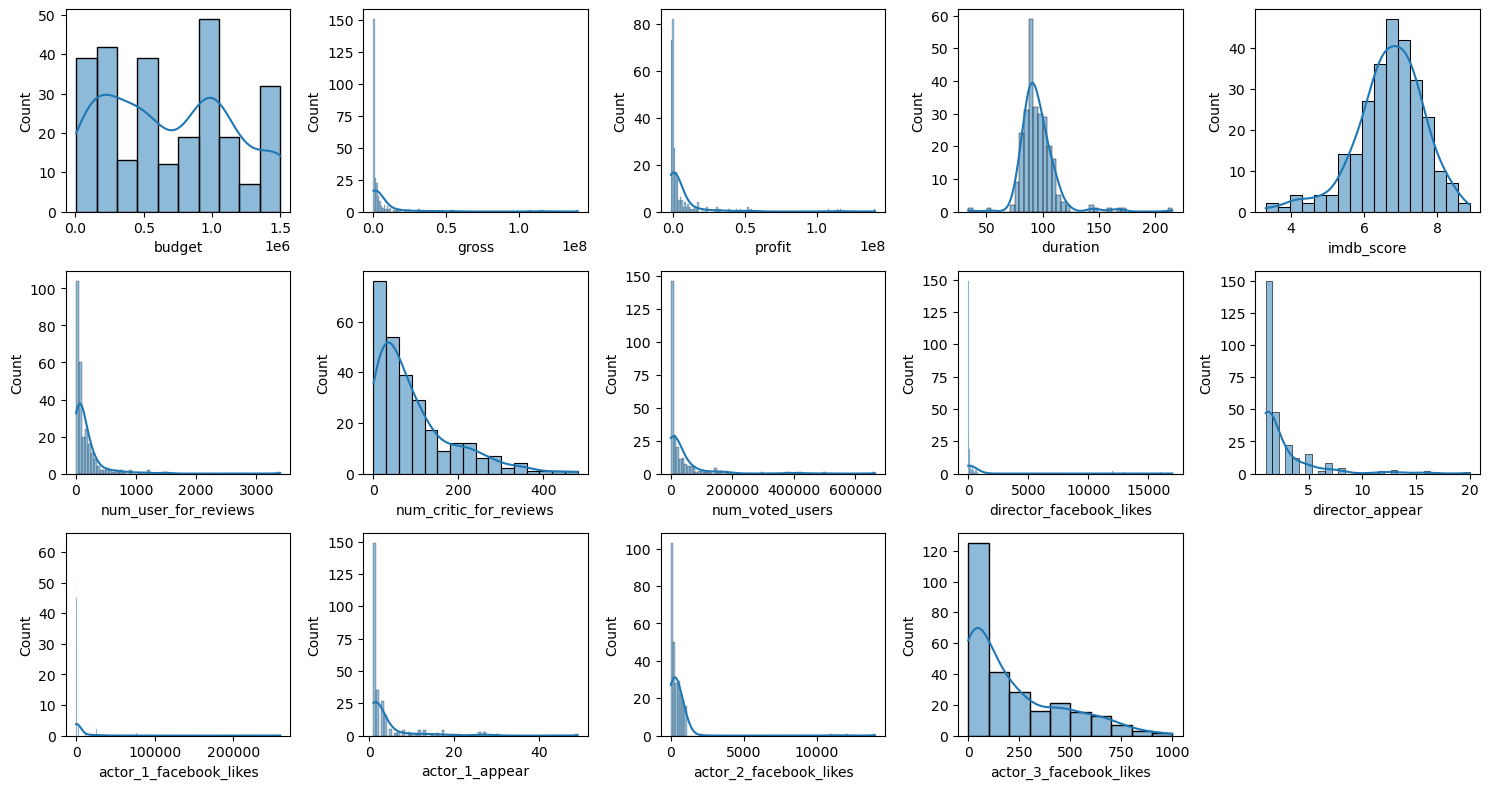

In [41]:
# visualize data
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15,8))
for column, ax in zip(con_list, axes.flat):
    sns.histplot(x=test_df[column], ax=ax, kde=True)
fig.tight_layout()
fig.delaxes(axes[2][4])

# Hypothesis testing

I will see if I can conduct hypothesis tests for the two columns and "profit" below.

In [42]:
test_list = ["director_appear", "actor_1_appear", "profit"]

I separated the data into two groups: "profit" > 0 and "profit" <= 0

In [43]:
test_df_n = test_df[test_list] # 4 cols

# separate the movies into two groups
plus_df = test_df_n[test_df_n["profit"] > 0] # profit > 0
minus_df = test_df_n[test_df_n["profit"] <= 0] # profit <= 0

In [44]:
plus_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 2044 to 3750
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   director_appear  148 non-null    int64  
 1   actor_1_appear   148 non-null    int64  
 2   profit           148 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 4.6 KB


In [45]:
minus_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 123 entries, 1201 to 3751
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   director_appear  123 non-null    int64  
 1   actor_1_appear   123 non-null    int64  
 2   profit           123 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 3.8 KB


### Hypothesis statements

Hypotheses I want to investigate are the following two:

If I hire a more experienced director, then the profit will be higher than 0  
If I hire a more experienced actor_1, then the profit will be higher than 0  

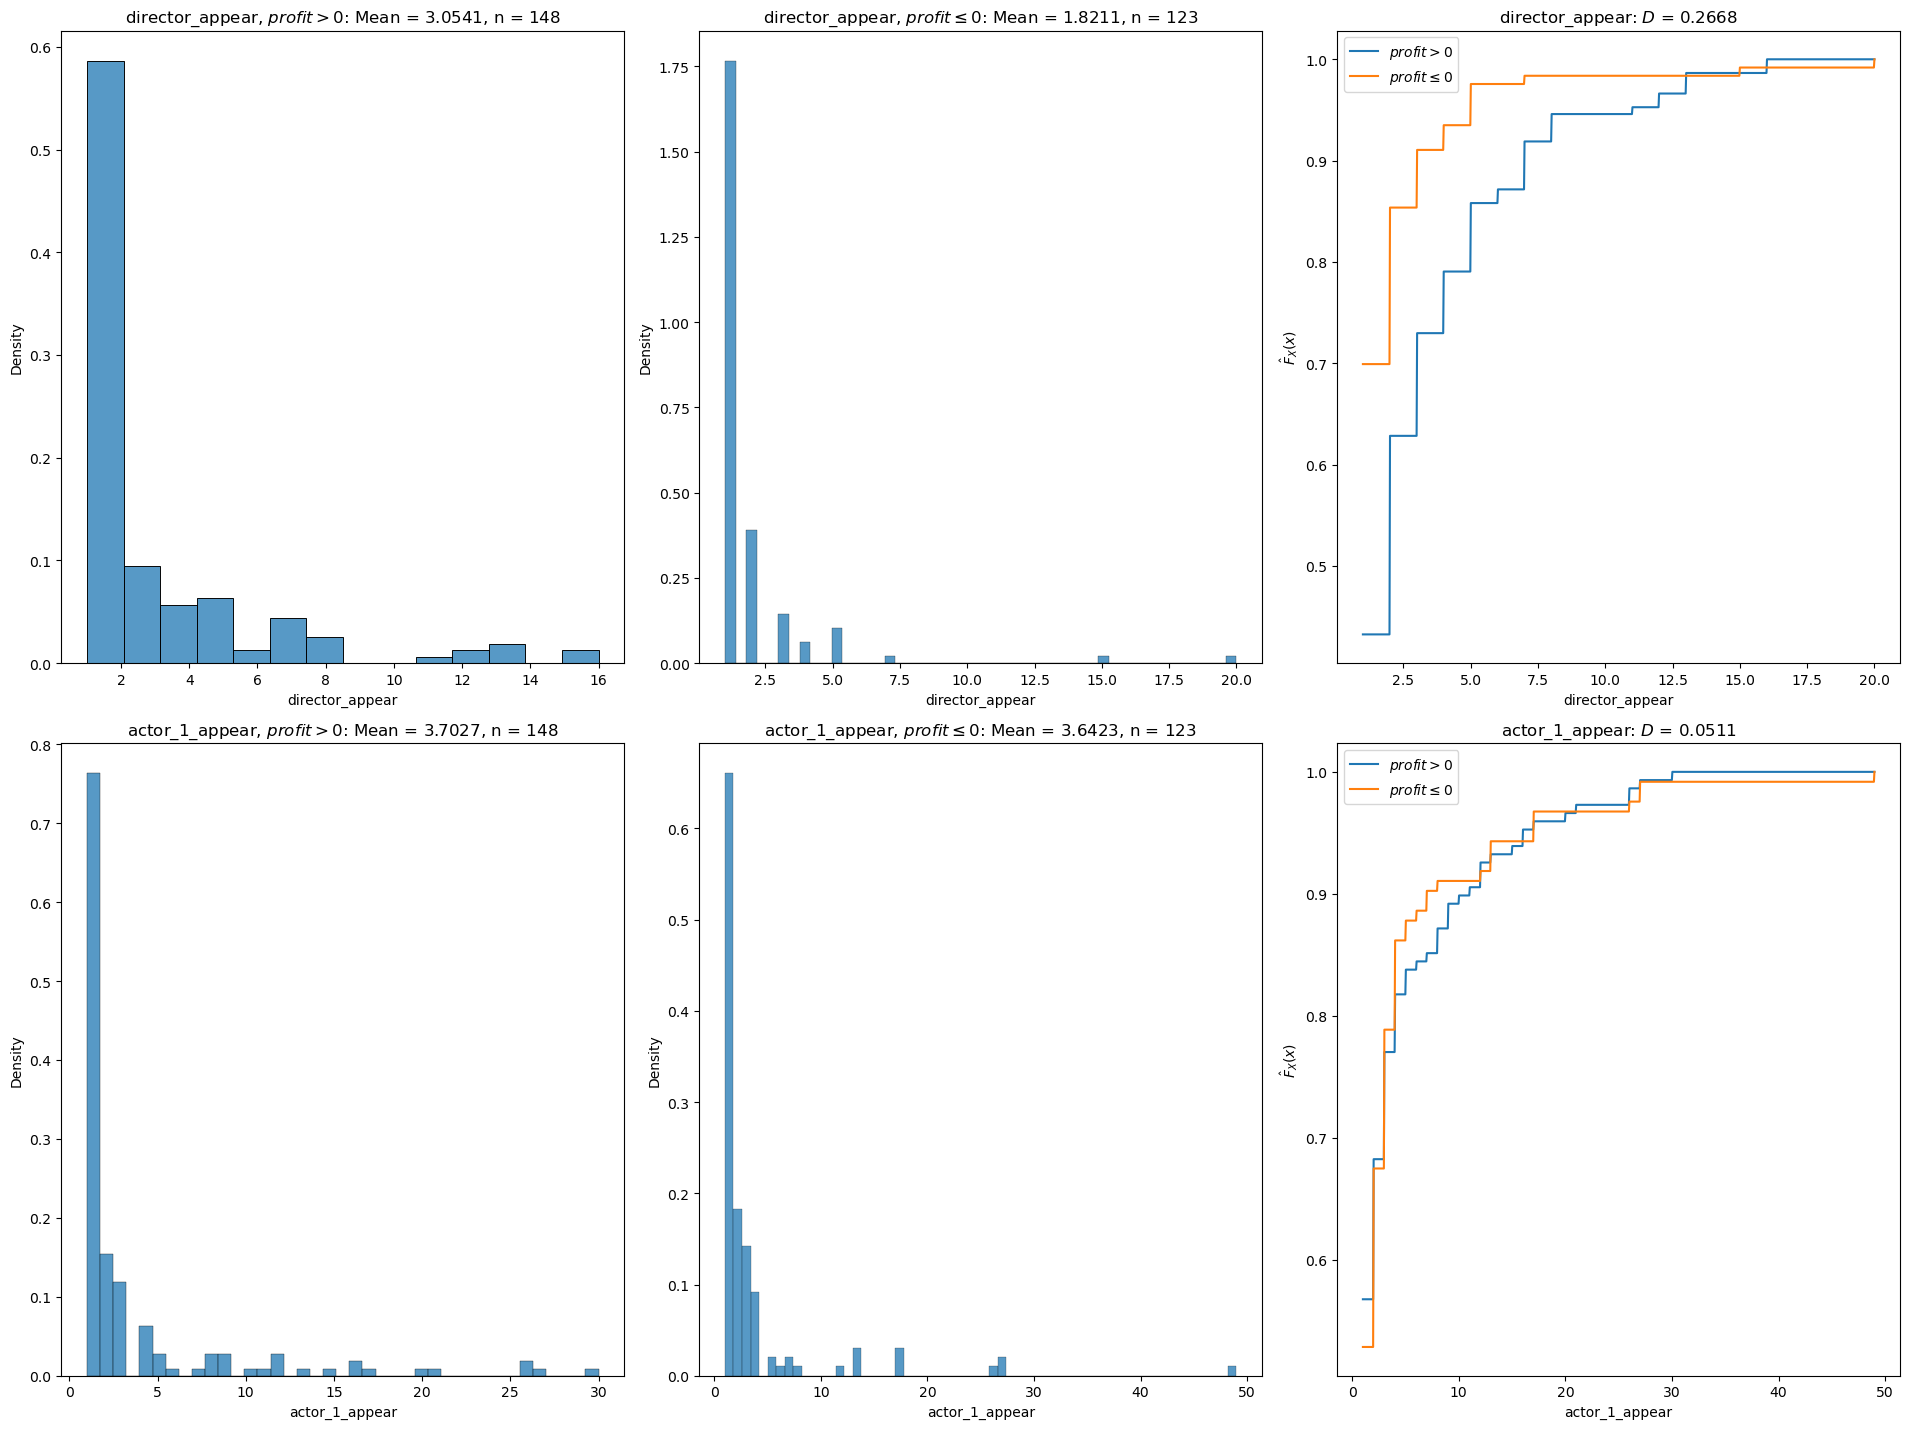

In [46]:
# check ECDF (from Lab_6_solns.ipynb)
from statsmodels.distributions.empirical_distribution import ECDF

fig, axes = plt.subplots(nrows = len(test_df_n.columns[:-1]), ncols = 3)

for idx, col in enumerate(plus_df.columns[:-1]):
    qual_str = [fr"$profit > 0$", fr"$profit \leq 0$"]
    for idx2, df in enumerate([plus_df,minus_df]):
        sns.histplot(data=df,ax=axes[idx,idx2],x=col,line_kws={"lw":2},stat="density")
        mean = df[col].mean()
        axes[idx,idx2].set_title(f"{col}, {qual_str[idx2]}: Mean = {mean:.4f}, n = {len(df)}")
        axes[idx,idx2].set_xlabel(col)

    quality_ECDF = ECDF(plus_df[col])
    low_quality_ECDF = ECDF(minus_df[col])
    xax = np.linspace(min(plus_df[col].min(),minus_df[col].min()),max(plus_df[col].max(),minus_df[col].max()) ,1001)
    axes[idx,2].plot(xax,quality_ECDF(xax),label=rf"$profit > 0$")
    axes[idx,2].plot(xax,low_quality_ECDF(xax),label=fr"$profit \leq 0$")
    axes[idx,2].legend(loc="best")

    D = np.max(np.abs(quality_ECDF(xax) - low_quality_ECDF(xax)))
    axes[idx,2].set_title(fr"{col}: $D$ = {D:.4f}")
    axes[idx,2].set_xlabel(col)
    axes[idx,2].set_ylabel(r"$\hat{F}_{X}(x)$")


fig.set_figwidth(fig.get_figwidth() * 3)
fig.set_figheight(fig.get_figheight() * len(plus_df.columns))
fig.tight_layout()

From the EDCF graph above, the distributions of plus and minus data for "actor_1_appear" seem to be close to each other. To statistically confirm this, I conducted Kolmogorov-Smirnoff tests; the hypothesis is below. 

\begin{align*}
\mathbf{H}_0 \quad &: \quad \textit{the sample groups come from the same distribution} \\
\mathbf{H}_1 \quad &: \quad \textit{the sample groups come from different distributions}
\end{align*}

In [47]:
# Kolmogorov-Smirnoff test(from Lab_6_solns.ipynb)
from scipy.stats import ks_2samp
alpha = 0.001

sig_cols = []

for idx, col in enumerate(plus_df.columns[:-1]):
    _,p_value_ks = ks_2samp(plus_df[col],minus_df[col])
    if p_value_ks < alpha:
        print(f"KS: The minus and plus profit distributions are significantly different for {col} at the {100*alpha}% significance level, p-value = {p_value_ks}")
        sig_cols.append(col)
    else:
        print(f"KS: The minus and plus profit distributions are not significantly different for {col} at the {100*alpha}% significance level, p-value = {p_value_ks}")

KS: The minus and plus profit distributions are significantly different for director_appear at the 0.1% significance level, p-value = 0.00010222856704305591
KS: The minus and plus profit distributions are not significantly different for actor_1_appear at the 0.1% significance level, p-value = 0.9892994321683508


In the next cell, I examined whether "director_appear" satisfies a Gaussian distribution.

\begin{align*}
\mathbf{H}_0 \quad &: \quad \textit{the samples come from a Gaussian distribution} \\
\mathbf{H}_1 \quad &: \quad \textit{the samples don't come from a Gaussian distribution}
\end{align*}

In [48]:
# D'Agostino's Ksquared test and Lilliefors(from Lab_6_solns.ipynb)
from scipy.stats import normaltest
from statsmodels.stats.diagnostic import lilliefors

norm_cols = []
not_norm_cols = [] 

for col in sig_cols:
    _,p_value_n_q = normaltest(plus_df[col])
    _,p_value_n_lq = normaltest(minus_df[col])
    
    if (p_value_n_q < alpha) or (p_value_n_lq < alpha):
        print(f"KSquared: At least one {col} distribution is statistically not Gaussian at the {100*alpha}% significance level")
        not_norm_cols.append(col)
    else:
        _,p_value_lf_q = lilliefors(plus_df[col],dist="norm")
        _,p_value_lf_lq = lilliefors(minus_df[col],dist="norm")
        
        if (p_value_lf_q > alpha) and (p_value_lf_lq > alpha):
            print(f"Lilliefors: Both {col} distributions are statistically Gaussian at the {100*alpha}% significance level")
            norm_cols.append(col)
        else:
            print(f"Lilliefors: At least one {col} distributions are not statistically Gaussian at the {100*alpha}% significance level")
            not_norm_cols.append(col)

KSquared: At least one director_appear distribution is statistically not Gaussian at the 0.1% significance level


"director_appear" does not follow a Gausian dictribution and t-test cannot be conducted, so I used bootstrap to predict confidence intervals.

In [49]:
# bootstrapping(from Lab_6_solns.ipynb)
def bootstrap_diff_means(data_1,data_2,num_bootstraps=10000,tail="two"):
    m_1 = np.mean(data_1)
    m_2 = np.mean(data_2)
    v_1 = np.var(data_1, ddof=1)
    v_2 = np.var(data_2, ddof=1)
    n_1 = len(data_1)
    n_2 = len(data_2)
    se = np.sqrt(v_1/n_1 + v_2/n_2)
    t_stat = (m_1 - m_2)/se

    comb_m = (np.sum(data_1) + np.sum(data_2))/(n_1 + n_2)

    adj_col1 = data_1 - m_1 + comb_m
    adj_col2 = data_2 - m_2 + comb_m

    count = 0
    for _ in range(num_bootstraps):
        bs_1 = np.array([adj_col1[i] for i in np.random.randint(0,n_1,size=n_1)])
        bs_2 = np.array([adj_col2[i] for i in np.random.randint(0,n_2,size=n_2)]) 
        
        bs_m_1 = np.mean(bs_1)
        bs_m_2 = np.mean(bs_2)
        bs_v_1 = np.var(bs_1,ddof=1)
        bs_v_2 = np.var(bs_2,ddof=1)
        bs_se = np.sqrt(bs_v_1/n_1 + bs_v_2/n_2)
        
        bs_t_stat = (bs_m_1 - bs_m_2)/bs_se
        
        if tail == "two":
            if np.abs(bs_t_stat) >= np.abs(t_stat):
                count += 1
        elif tail == "less":
            if bs_t_stat <= t_stat:
                count += 1
        elif tail == "greater":
            if bs_t_stat >= t_stat:
                count += 1

    return m_1 - m_2, t_stat, (count+1)/(num_bootstraps+1)

Here, to statistically examine whether hiring a more experienced director is expected to result in higher profits than 0, I conducted the following hypothesis test.

\begin{align*}
\mathbf{H}_0 \quad &: \quad \mu_{plus} - \mu_{minus} = 0 \\
\mathbf{H}_1 \quad &: \quad \mu_{plus} - \mu_{minus} > 0
\end{align*}

In [50]:
# scores(from Lab_6_solns.ipynb)
sig_mean_cols = []
dbars = [] 
for col in not_norm_cols:
    
    data_1 = plus_df[col].to_numpy()
    data_2 = minus_df[col].to_numpy()
    
    if np.mean(data_1) - np.mean(data_2) < 0:
        tail = "less"
    else:
        tail = "greater"
    
    dbar, _, p_value_bs = bootstrap_diff_means(data_1,data_2,tail=tail)
    if p_value_bs < alpha:
        print(f"Bootstrap: There is significant evidence to state that the average number of {col} for profit > 0 is greater to profit <= 0 at the {100*alpha}% significance level, p-value = {p_value_bs}")
        sig_mean_cols.append(col)
        dbars.append(dbar)
    else:
        print(f"Bootstrap: There is not significant evidence to state that the average nuber of {col} for profit > 0 is different to profit <= 0 at the {100*alpha}% significance level, p-value = {p_value_bs}")

Bootstrap: There is significant evidence to state that the average number of director_appear for profit > 0 is greater to profit <= 0 at the 0.1% significance level, p-value = 9.999000099990002e-05


# Summary

In this analysis of movie data to extract key features for a profitable movie production, I found the following insights.

Firstly, color movies tend to be more profitable. 

Additionally, considering the less favorable combination of "Comedy" and "Thriller" in the last movie, I explored genres where relatively low budgets could lead to high profits. Genres such as "Music", "Family", and "Adventure" emerged as strong candidates. However, a decision needs to be made on which one to choose and explore combinations with the other genres. 

Lastly, the hypothesis test confirmed that movies directed by more experienced directors tend to yield higher profits. However, it's important to recognize the presence of older directors, with some potentially having already passed away.

From these findings, it seems promising to consider producing a color movie with either "Music", "Family", or "Adventure" genre, led by a more experienced director for the next movie although there are some points to keep in mind.

In [51]:
# the directors that satisfies the criteria above
# "Terry Gilliam", "George Lucas(Star Wars director)", and "Terence Young(He has passed away)" sound promising

f_df = test_df[(test_df["genres"].str.contains("Music")) | (test_df["genres"].str.contains("Family")) | (test_df["genres"].str.contains("Adventure"))]
f_df[(f_df["profit"] > 0) & (f_df["color"] == "Color")][["director_name", "director_appear"]]

,director_name,director_appear
3397,Randall Miller,2
3518,Youssef Delara,2
3544,Terence Young,4
3550,Duncan Tucker,1
3552,Russ Meyer,1
3557,Morgan Neville,1
3606,Ryan Little,1
3607,George Lucas,5
3608,Matt Maiellaro,1
3621,Michael Wadleigh,1


In [52]:
# write the notebook filepath here
# make sure that the notebook is also in the same directory as this code
filepath="Movie_Data_Analysis.ipynb"

In [53]:
import io
from nbformat import read
with io.open(filepath, "r", encoding="utf-8") as f:
    nb=read(f, 4)
word_count = 0
for cell in nb["cells"]:
    if cell.cell_type == "markdown":
        word_count += len(cell["source"].replace("#", "").lstrip().split(" "))
print(f"Submission length is {word_count}")

Submission length is 961
